# Spam classifier

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as opt 
import sklearn.metrics
from sklearn.utils  import shuffle


In [2]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [3]:

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## data processing (from tutorial)

importing csv and word2indexing

In [4]:
# from sklearn.utils import shuffle


# df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
# df.head()
# # rename columns to something better
# df.columns = ['labels', 'data']
# # create binary labels
# df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1})

# df_train, df_test = train_test_split(df, test_size=0.33)
# df_train.shape, df_test.shape


# # 0 = padding
# idx = 1
# word2idx = {'<PAD>': 0}
# # you could always use gensim or spacy for tokenization,
# # but let's keep it simple!
# for i, row in df_train.iterrows():
#   tokens = row['data'].lower().split() # simple tokenization
#   for token in tokens:
#     if token not in word2idx:
#       word2idx[token] = idx
#       idx += 1

# word2idx
# len(word2idx)

# # convert data into word indices
# # note: could have done this on the fly earlier
# train_sentences_as_int = []
# for i, row in df_train.iterrows():
#   tokens = row['data'].lower().split()
#   sentence_as_int = [word2idx[token] for token in tokens]
#   train_sentences_as_int.append(sentence_as_int)


# test_sentences_as_int = []
# for i, row in df_test.iterrows():
#   tokens = row['data'].lower().split()
#   sentence_as_int = [word2idx[token] for token in tokens if token in word2idx]
#   test_sentences_as_int.append(sentence_as_int)


# len(train_sentences_as_int), len(test_sentences_as_int) 



creating data generators


In [5]:
# def data_generator(X, y, batch_size=32):
#   X, y = shuffle(X, y)
#   n_batches = int(np.ceil(len(y) / batch_size))
#   for i in range(n_batches):
#     end = min((i + 1) * batch_size, len(y))

#     X_batch = X[i * batch_size:end]
#     y_batch = y[i * batch_size:end]

#     # pad X_batch to be N x T
#     max_len = np.max([len(x) for x in X_batch])
#     for j in range(len(X_batch)):
#       x = X_batch[j]
#       pad = [0] * (max_len - len(x))
#       X_batch[j] = pad + x
    
#     # convert to tensor
#     X_batch = torch.from_numpy(np.array(X_batch)).long()
#     y_batch = torch.from_numpy(np.array(y_batch)).long()
    
#     yield X_batch, y_batch




example of usage

In [6]:
# for inputs, targets in data_generator(train_sentences_as_int, df_train.b_labels):
#   print("inputs", inputs, "shape:", inputs.shape)
#   print("targets", targets, "shape:", targets.shape)
#   break

## data processing (mine)

In [4]:
df['spam'] = df['v1'].map({'ham': 0, 'spam': 1})
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4','v1'])
df.columns = ['data', 'spam']
df.head()

,data,spam
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [5]:
corpus,y = df['data'].values,df['spam'].values

In [6]:
class Word2index:
    def __init__(self):
        self.PADDING = 0 
        self.word2idx ={'<pad>':self.PADDING,'<unknown>':1}
        self.current_index = 2
        

    def add(self,word):
        if  word.lower() not in self.word2idx:
            self.word2idx[word.lower()] = self.current_index
            self.current_index += 1
        return self.get_index_from_word(word.lower())
    
    def get_index_from_word(self,word)->int:
        if  word.lower() in self.word2idx:
            return self.word2idx[word.lower()]
        
       
        return self.word2idx['<unknown>']
        

    def get_vocab_size(self):
        return len(self.word2idx)

    def make_reverse(self):
        self.idx2word = {}
        for word,i in self.word2idx.items():
            self.idx2word[i] = word
    
    def index_to_word(self,i)->str:
        if i in self.idx2word:
            return self.idx2word[i]
    



my data generator

In [7]:
class DataGenerator:
    def __init__(self,corpus,labels):
        self.word2indexDict = Word2index()
        self.__proccess_corpus__(corpus=corpus)
        self.y = labels

    def __proccess_corpus__(self,corpus):
        self.texts = []
        self.max_row_size = 0
        for text in corpus:
            text = str(text)

            text = re.sub('[^a-zA-Z0-9 ]+','',text)
            row = re.split(' ',text)
            self.max_row_size = np.max([self.max_row_size,len(row)])
            row = [x for x in row if x != '']
            self.texts.append(row)

    def train_test_split(self,test_percentage=0.25):

        
        X_train,X_test,self.y_train, self.y_test = train_test_split(self.texts,self.y,test_size=test_percentage)


        self.X_train = []
        for sample in X_train:
            sentence = []

            for word in sample:
                index = self.word2indexDict.add(word)
                assert index is not None and index == self.word2indexDict.get_index_from_word(word) and index >= 0
                sentence.append(index)
            self.X_train.append(sentence)
        self.word2indexDict.make_reverse()
        
        self.X_test = []
        for sample in X_test:
            sentence = []
            for word in sample:
                index = self.word2indexDict.get_index_from_word(word)
                assert index is not None and  index == self.word2indexDict.get_index_from_word(word) and index >= 0
                sentence.append(index)

            self.X_test.append(sentence)

      

    def  generate_helper(self,X,y,batch_size=32):
        num_batches = int(np.ceil(len(y)/batch_size))


        for i in range(num_batches):
            end = min(len(y),(i+1)*batch_size)
            X_batch = X[i*batch_size: end]
            y_batch = y[i*batch_size: end]

            for j in range(len(X_batch)):
                X_batch[j] = [self.word2indexDict.PADDING] * (self.max_row_size - len(X_batch[j])) + X_batch[j]

                    # convert to tensor
            y_batch = y_batch.reshape(-1,1)
            X_batch = torch.from_numpy(np.array(X_batch)).long()
            y_batch = torch.from_numpy(np.array(y_batch).astype(np.float32))
            
            yield X_batch, y_batch.float()

    def generate_train(self,batch_size=32):
  
        X,y = shuffle(self.X_train,self.y_train)
        return self.generate_helper(X,y,batch_size=batch_size)
    
    def generate_test(self,batch_size=32):

        X,y = self.X_test,self.y_test

        return self.generate_helper(X,y,batch_size=batch_size)
    

In [8]:
dg = DataGenerator(corpus=corpus,labels=y)
dg.train_test_split(0.25)


In [9]:
for word,i in dg.word2indexDict.word2idx.items():
    print(word,i)
    if i > 5:
        break

<pad> 0
<unknown> 1
don 2
no 3
dawhats 4
you 5
plan 6


In [10]:
for x,y in dg.generate_train(batch_size=1):
    if x.shape[1] != 171:
          print('Not 171',x.shape[1],x)
          break
    for l in range(x.shape[0]):
        for i in x[l]:
            w = dg.word2indexDict.index_to_word(i.item())
            if w is None:
                    print('None',l,i.item())
                    break
           
 



In [11]:
for x1,y1 in dg.generate_test(batch_size=64):
    for l in range(x1.shape[0]):
            for i in x1[l]:
                w = dg.word2indexDict.index_to_word(i.item())
                if w is None:
                    print('None',x1,i.item())
                    break
                if w != '<pad>':
                    print(w,end=' ')
                
            print(' - ',y1[l])
    print('+'*51)
    break



that is <unknown> song  -  tensor([0.])
wot student discount can u get on books  -  tensor([0.])
went to pay rent so i had to go to the bank to <unknown> the payment  -  tensor([0.])
sorry ill call later ok bye  -  tensor([0.])
how are you wish you a great semester  -  tensor([0.])
26th of july  -  tensor([0.])
almost there see u in a sec  -  tensor([0.])
captain <unknown> is doing comedy in captain <unknown> is drunken  -  tensor([0.])
i am in escape theatre now going to watch <unknown> in a few minutes  -  tensor([0.])
dear we are going to our <unknown> place  -  tensor([0.])
have you <unknown> <unknown> and also your time off how are you by the way  -  tensor([0.])
its a great day do have yourself a beautiful one  -  tensor([0.])
you please give us connection today itself before ltdecimalgt or <unknown> the bill  -  tensor([0.])
mila age23 blonde new in uk i look sex with uk guys if u like fun with me text mtalk to 6986618 30pptxt 1st 5free 150 increments help08718728876  -  tensor(

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [13]:
class RNN(nn.Module):
    def __init__(self,num_vocab,embed_dim,n_hidden,rnn_layers,n_outputs,bidi=False):
        super(RNN, self).__init__()

        self.V = num_vocab
        self.D = embed_dim
        self.M = n_hidden
        self.L = rnn_layers
        self.K = n_outputs
        self.bidirectional = bidi

        factor = 1 if not self.bidirectional else 2 
        self.embed = nn.Embedding(self.V, self.D)
        self.rnn = nn.LSTM(input_size=self.D,
                           hidden_size=self.M,
                           num_layers=self.L,batch_first=True,
                           bidirectional=self.bidirectional)
        
        self.fc = nn.Linear(factor*self.M,self.K)

    def forward(self,X):
        
        factor = 1 if not self.bidirectional else 2
        h0 = torch.zeros(factor*self.L,X.size(0),self.M).to(device)
        c0 = torch.zeros(factor*self.L,X.size(0),self.M).to(device)
        x = self.embed(X) #NxTxD


        x,(h_n,c_n) = self.rnn(x,(h0,c0)) # NxTxM*factor
     
        x,_ = torch.max(x,1) # NxM*factor
 
        return self.fc(x)
        
        

In [14]:
VOCAB_SIZE = dg.word2indexDict.get_vocab_size() # vocab size
EMBEDDED_DIM = 60 #latent dimension #D
NUM_LAYERS = 2 #L
HIDDEN_UNITS = 16 #M
OUTPUTS = 1 #k
BIDIRECTIONAL= True
num_epochs = 100
BATCH_SIZE = 128

In [15]:
model = RNN(num_vocab=VOCAB_SIZE,
            embed_dim=EMBEDDED_DIM,
            n_hidden=HIDDEN_UNITS,
            rnn_layers=NUM_LAYERS,
            n_outputs=OUTPUTS,
            bidi=BIDIRECTIONAL            
            )
model.to(device)
print(model)
criterion = nn.BCEWithLogitsLoss()
optimizer = opt.Adam(model.parameters(),lr=0.001)


RNN(
  (embed): Embedding(8103, 60)
  (rnn): LSTM(60, 16, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## training and evaluating(tutorial)

In [19]:
# import matplotlib.pyplot as plt
# import torch

# # Clear GPU cache before starting the training loop
# torch.cuda.empty_cache()

# # Training loop
# num_epochs = 100
# train_losses = []
# test_losses = []

# # Reduce batch size to decrease memory usage
# batch_size = 128

# for epoch in range(num_epochs):
#     model.train()
#     train_loss = 0.0
#     for X_batch, y_batch in data_generator(train_sentences_as_int,df_train.b_labels,batch_size=batch_size):
#         # Clear GPU cache before each batch
#         torch.cuda.empty_cache()
#         y_batch = y_batch.reshape(-1,1)
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device).float()
#         optimizer.zero_grad()
#         outputs = model(X_batch)
#         loss = criterion(outputs, y_batch)
#         loss.backward()
#         optimizer.step()
        
#         train_loss += loss.item()
    
#     train_loss /= len(df_train.b_labels)
#     train_losses.append(train_loss)
    
#     # Evaluate on test data
#     model.eval()
#     test_loss = 0.0
#     with torch.no_grad():
#         for X_batch, y_batch in data_generator(test_sentences_as_int, df_test.b_labels, batch_size=batch_size):
#             # Clear GPU cache before each batch     
#             torch.cuda.empty_cache()
#             X_batch, y_batch = X_batch.to(device), y_batch.to(device).float()
#             outputs = model(X_batch)
#             y_batch = y_batch.reshape(-1,1)
#             loss = criterion(outputs, y_batch)
#             test_loss += loss.item()
    
#     test_loss /= len(df_test.b_labels)
#     test_losses.append(test_loss)
    
#     print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

# # Plotting the train and test loss graphs
# plt.figure(figsize=(10, 5))
# plt.plot(train_losses, label='Train Loss')
# plt.plot(test_losses, label='Test Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Train and Test Loss')
# plt.legend()
# plt.show()

In [20]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# # Get predictions from the model
# model.eval()
# y_true = []
# y_pred = []

# with torch.no_grad():
#     for X_batch, y_batch in data_generator(test_sentences_as_int, df_test.b_labels, batch_size=batch_size):
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device).float()
#         outputs = model(X_batch)
#         predictions = (torch.sigmoid(outputs) > 0.5).int()
#         y_true.extend(y_batch.cpu().numpy())
#         y_pred.extend(predictions.cpu().numpy())

# # Generate confusion matrix
# cm = confusion_matrix(y_true, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
# disp.plot(cmap='Blues')
# plt.title('Confusion Matrix')
# plt.show()

In [21]:
# from sklearn.metrics import roc_curve, auc

# # Get predictions and true labels
# model.eval()
# y_true = []
# y_scores = []

# with torch.no_grad():
#     for X_batch, y_batch in data_generator(test_sentences_as_int, df_test.b_labels, batch_size=batch_size):
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device).float()
#         outputs = model(X_batch)
#         y_true.extend(y_batch.cpu().numpy())
#         y_scores.extend(torch.sigmoid(outputs).cpu().numpy())

# # Compute ROC curve and AUC
# fpr, tpr, _ = roc_curve(y_true, y_scores)
# roc_auc = auc(fpr, tpr)

# # Plot the ROC curve
# plt.figure(figsize=(10, 5))
# plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
# plt.legend(loc="lower right")
# plt.show()

In [22]:
# df.columns

In [23]:
train_losses = []
test_losses = []


for epoch in range(num_epochs):
    avg_loss = []
    for X_train,y_train in dg.generate_train(batch_size=BATCH_SIZE):
        # Clear GPU cache before each batch
        torch.cuda.empty_cache()
        X_train, y_train = X_train.to(device), y_train.to(device).float()
        y_train = y_train.reshape(-1,1)
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        avg_loss.append(loss.item())
    train_losses.append(np.mean(avg_loss))


    avg_loss = []
    with torch.no_grad():
        for X_test,y_test in dg.generate_test(batch_size=BATCH_SIZE):
            X_test, y_test = X_test.to(device), y_test.to(device).float()
            y_test = y_test.reshape(-1,1)
            outputs = model(X_test)
            loss = criterion(outputs, y_test)
            avg_loss.append(loss.item())   
        test_losses.append(np.mean(avg_loss))
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}")

    

Epoch 1/100, Train Loss: 0.5410, Test Loss: 0.4034
Epoch 2/100, Train Loss: 0.3964, Test Loss: 0.3587
Epoch 3/100, Train Loss: 0.3709, Test Loss: 0.3330
Epoch 4/100, Train Loss: 0.3146, Test Loss: 0.2564
Epoch 5/100, Train Loss: 0.1900, Test Loss: 0.1676
Epoch 6/100, Train Loss: 0.1052, Test Loss: 0.1110
Epoch 7/100, Train Loss: 0.0693, Test Loss: 0.1378
Epoch 8/100, Train Loss: 0.0529, Test Loss: 0.1205
Epoch 9/100, Train Loss: 0.0422, Test Loss: 0.1133
Epoch 10/100, Train Loss: 0.0348, Test Loss: 0.1162
Epoch 11/100, Train Loss: 0.0290, Test Loss: 0.1331
Epoch 12/100, Train Loss: 0.0246, Test Loss: 0.1197
Epoch 13/100, Train Loss: 0.0216, Test Loss: 0.1163
Epoch 14/100, Train Loss: 0.0192, Test Loss: 0.1146
Epoch 15/100, Train Loss: 0.0177, Test Loss: 0.1194
Epoch 16/100, Train Loss: 0.0150, Test Loss: 0.1189
Epoch 17/100, Train Loss: 0.0180, Test Loss: 0.1090
Epoch 18/100, Train Loss: 0.0107, Test Loss: 0.1209
Epoch 19/100, Train Loss: 0.0093, Test Loss: 0.1226
Epoch 20/100, Train L

# metrics

Text(0, 0.5, 'Loss')

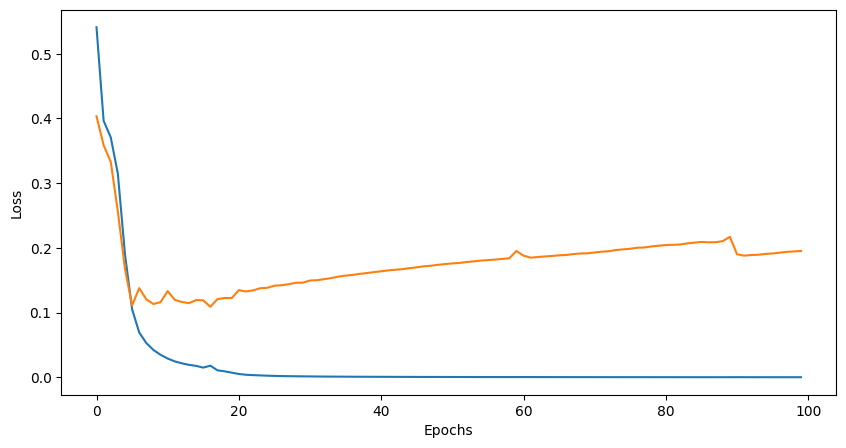

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')  


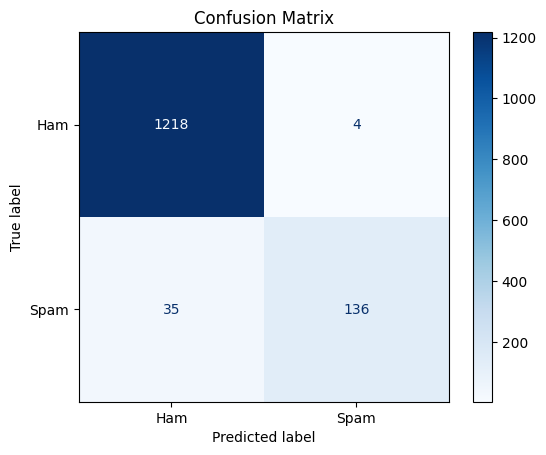

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from the model
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in dg.generate_test(batch_size=BATCH_SIZE):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device).float()
        outputs = model(X_batch)
        predictions = (torch.sigmoid(outputs) > 0.5).int()
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

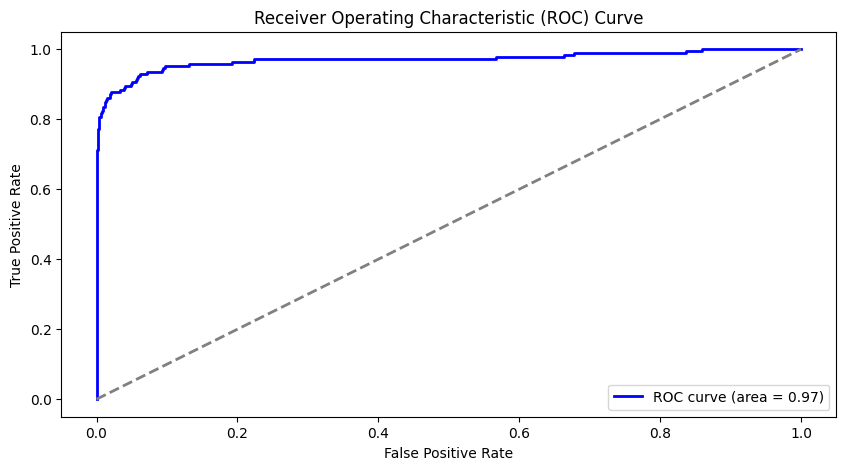

In [26]:
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

# Get predictions and true labels
model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for X_batch, y_batch in dg.generate_test(batch_size=BATCH_SIZE):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device).float()
        outputs = model(X_batch)
        y_true.extend(y_batch.cpu().numpy())
        y_scores.extend(torch.sigmoid(outputs).cpu().numpy())

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [17]:
train_losses = []
for epoch in range(num_epochs):
    torch.cuda.empty_cache()
    losses = []
    for X_train,y_train in dg.generate_train(batch_size=128):
        optimizer.zero_grad()
        X_train, y_train = X_train.to(device), y_train.to(device).float()
        y_hat = model(X_train)
        y_train = y_train.reshape(-1,1)
        loss = criterion(y_hat, y_train)
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
            losses.append(loss.item())

    train_losses.append(np.mean(losses))
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {np.mean(losses)}")
        

Epoch 0, Loss: 0.42458999156951904
Epoch 0, Loss: 0.4425676763057709
Epoch 0, Loss: 0.3750765919685364
Epoch 0, Loss: 0.3964158594608307
Epoch 0, Loss: 0.4174628257751465
Epoch 0, Loss: 0.38041555881500244
Epoch 0, Loss: 0.4398861527442932
Epoch 0, Loss: 0.3878380358219147
Epoch 0, Loss: 0.32670822739601135
Epoch 0, Loss: 0.4611683785915375
Epoch 0, Loss: 0.42225539684295654
Epoch 0, Loss: 0.2970031201839447
Epoch 0, Loss: 0.30453425645828247
Epoch 0, Loss: 0.3688638210296631
Epoch 0, Loss: 0.4599524736404419
Epoch 0, Loss: 0.44831469655036926
Epoch 0, Loss: 0.39466413855552673
Epoch 0, Loss: 0.3514421582221985
Epoch 0, Loss: 0.33652907609939575
Epoch 0, Loss: 0.378274142742157
Epoch 0, Loss: 0.4495235085487366
Epoch 0, Loss: 0.3485119640827179
Epoch 0, Loss: 0.2788524031639099
Epoch 0, Loss: 0.36558544635772705
Epoch 0, Loss: 0.33192387223243713
Epoch 0, Loss: 0.44629234075546265
Epoch 0, Loss: 0.3314191997051239
Epoch 0, Loss: 0.4038494825363159
Epoch 0, Loss: 0.35629260540008545
Epo

c:\Users\liora\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\liora\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Epoch 10, Loss: 0.04356672614812851
Epoch 10, Loss: 0.0428866446018219
Epoch 10, Loss: 0.013618143275380135
Epoch 10, Loss: 0.04373983293771744
Epoch 10, Loss: 0.010920592583715916
Epoch 10, Loss: 0.018248409032821655
Epoch 10, Loss: 0.01190969068557024
Epoch 10, Loss: 0.08027548342943192
Epoch 10, Loss: 0.1157476007938385
Epoch 10, Loss: 0.013553488068282604
Epoch 10, Loss: 0.04587641730904579
Epoch 10, Loss: 0.031079739332199097
Epoch 10, Loss: 0.01139237079769373
Epoch 10, Loss: 0.013591197319328785
Epoch 10, Loss: 0.011761940084397793
Epoch 10, Loss: 0.012751277536153793
Epoch 10, Loss: 0.012080039829015732
Epoch 10, Loss: 0.011298655532300472
Epoch 10, Loss: 0.012685964815318584
Epoch 10, Loss: 0.016307566314935684
Epoch 10, Loss: 0.011342550627887249
Epoch 10, Loss: 0.07521987706422806
Epoch 10, Loss: 0.06396743655204773
Epoch 10, Loss: 0.013175060972571373
Epoch 10, Loss: 0.011374009773135185
Epoch 10, Loss: 0.013026837259531021
Epoch 10, Loss: 0.0341855064034462
Epoch 10, Loss: